In [10]:
from pathlib import Path
import sys

import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent

sys.path.insert(
    0,
    str(PROJECT_ROOT),
)

In [11]:
from src.risk.stress_testing import (
    run_stress_scenarios,
)

stress_results = (
    run_stress_scenarios()
)

stress_results

,scenario,description,base_portfolio_value,stress_pnl,stressed_value
0,Equity Down 10%,Broad equity market decline,5.233440e+06,-29439.758644,5.204001e+06
1,Equity Crash + Volatility Spike,Equity selloff accompanied by volatility increase,5.233440e+06,-44298.773656,5.189142e+06
2,Rates Up 100bp,Parallel upward rate shock,5.233440e+06,434787.922852,5.668228e+06
3,Rates Down 100bp,Parallel downward rate shock,5.233440e+06,-434787.922852,4.798652e+06
4,Combined Market Shock,"Equity decline, volatility increase and rates ...",5.233440e+06,375669.368917,5.609110e+06


In [12]:
stress_results[
    [
        "scenario",
        "stress_pnl",
        "stressed_value",
    ]
]

,scenario,stress_pnl,stressed_value
0,Equity Down 10%,-29439.758644,5.204001e+06
1,Equity Crash + Volatility Spike,-44298.773656,5.189142e+06
2,Rates Up 100bp,434787.922852,5.668228e+06
3,Rates Down 100bp,-434787.922852,4.798652e+06
4,Combined Market Shock,375669.368917,5.609110e+06


In [13]:
stress_results.sort_values(
    "stress_pnl"
)

,scenario,description,base_portfolio_value,stress_pnl,stressed_value
3,Rates Down 100bp,Parallel downward rate shock,5.233440e+06,-434787.922852,4.798652e+06
1,Equity Crash + Volatility Spike,Equity selloff accompanied by volatility increase,5.233440e+06,-44298.773656,5.189142e+06
0,Equity Down 10%,Broad equity market decline,5.233440e+06,-29439.758644,5.204001e+06
4,Combined Market Shock,"Equity decline, volatility increase and rates ...",5.233440e+06,375669.368917,5.609110e+06
2,Rates Up 100bp,Parallel upward rate shock,5.233440e+06,434787.922852,5.668228e+06


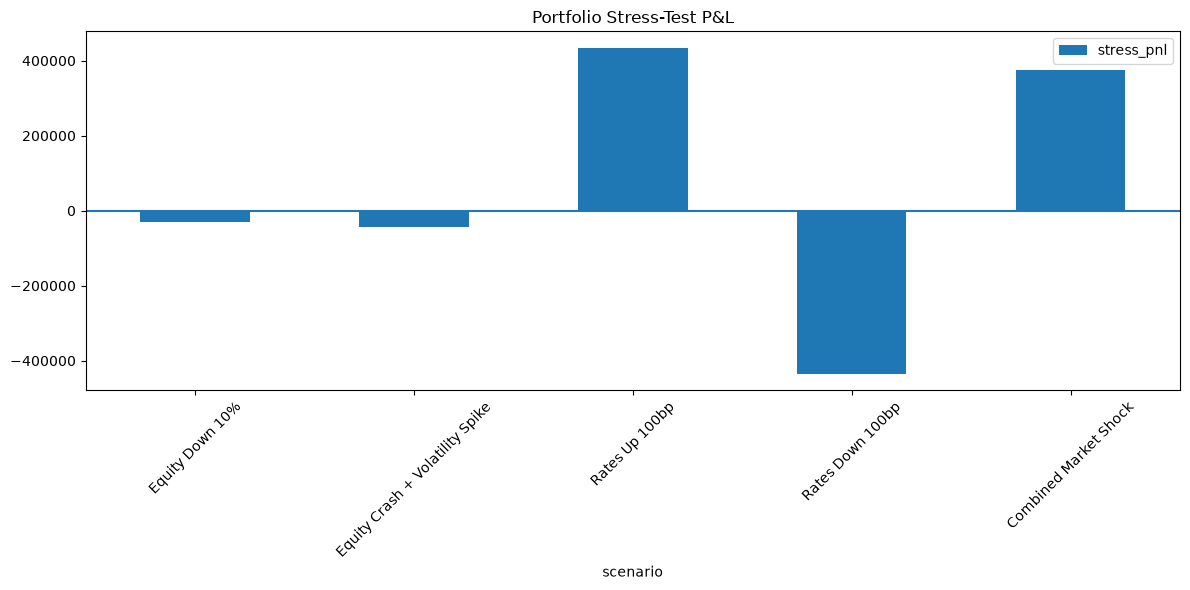

In [14]:
stress_results.plot(
    x="scenario",
    y="stress_pnl",
    kind="bar",
    figsize=(12, 6),
    title="Portfolio Stress-Test P&L",
)

plt.axhline(0)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [15]:
stress_results.to_csv(
    PROJECT_ROOT
    / "reports"
    / "stress_results.csv",
    index=False,
)